In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load analytical dataset
df = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset.csv')

print("="*60)
print("ANALYTICAL DATASET — BASIC SUMMARY")
print("="*60)
print(f"\nShape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nDescriptive statistics:")
print(df[['prescribing_rate_mean', 'imd_score_mean', 
          'retail_accessibility_score', 'months_zero']].describe().round(3))

ANALYTICAL DATASET — BASIC SUMMARY

Shape: (106, 16)

Dtypes:
org_id                         object
org_name                       object
prescribing_rate_mean         float64
prescribing_rate_median       float64
prescribing_rate_max          float64
months_zero                     int64
imd_score_mean                float64
income_score_mean             float64
health_score_mean             float64
education_score_mean          float64
retail_accessibility_score    float64
total_stores                    int64
quality_stores                  int64
regular_stores                  int64
budget_stores                   int64
n_lsoas                         int64
dtype: object

Descriptive statistics:
       prescribing_rate_mean  imd_score_mean  retail_accessibility_score  \
count                106.000         106.000                     106.000   
mean                   9.370          22.750                       0.282   
std                    8.430           7.379                   

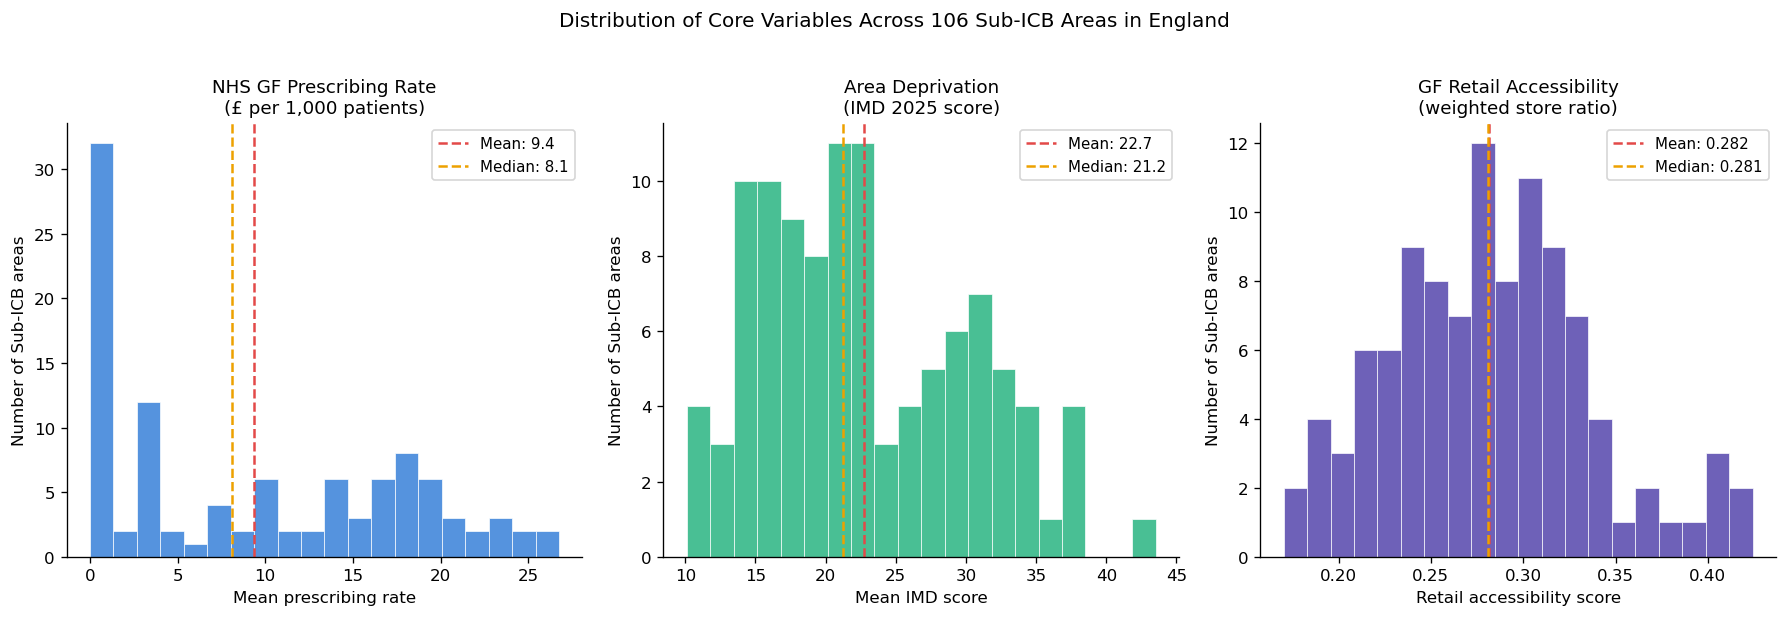

Saved.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Prescribing rate distribution
axes[0].hist(df['prescribing_rate_mean'], bins=20, color='#2a78d6', 
             alpha=0.8, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['prescribing_rate_mean'].mean(), color='#e34948', 
                linewidth=1.5, linestyle='--', label=f"Mean: {df['prescribing_rate_mean'].mean():.1f}")
axes[0].axvline(df['prescribing_rate_mean'].median(), color='#eda100', 
                linewidth=1.5, linestyle='--', label=f"Median: {df['prescribing_rate_mean'].median():.1f}")
axes[0].set_title('NHS GF Prescribing Rate\n(£ per 1,000 patients)', fontsize=11)
axes[0].set_xlabel('Mean prescribing rate')
axes[0].set_ylabel('Number of Sub-ICB areas')
axes[0].legend(fontsize=9)

# 2. IMD score distribution
axes[1].hist(df['imd_score_mean'], bins=20, color='#1baf7a', 
             alpha=0.8, edgecolor='white', linewidth=0.5)
axes[1].axvline(df['imd_score_mean'].mean(), color='#e34948', 
                linewidth=1.5, linestyle='--', label=f"Mean: {df['imd_score_mean'].mean():.1f}")
axes[1].axvline(df['imd_score_mean'].median(), color='#eda100', 
                linewidth=1.5, linestyle='--', label=f"Median: {df['imd_score_mean'].median():.1f}")
axes[1].set_title('Area Deprivation\n(IMD 2025 score)', fontsize=11)
axes[1].set_xlabel('Mean IMD score')
axes[1].set_ylabel('Number of Sub-ICB areas')
axes[1].legend(fontsize=9)

# 3. Retail accessibility distribution
axes[2].hist(df['retail_accessibility_score'], bins=20, color='#4a3aa7', 
             alpha=0.8, edgecolor='white', linewidth=0.5)
axes[2].axvline(df['retail_accessibility_score'].mean(), color='#e34948', 
                linewidth=1.5, linestyle='--', label=f"Mean: {df['retail_accessibility_score'].mean():.3f}")
axes[2].axvline(df['retail_accessibility_score'].median(), color='#eda100', 
                linewidth=1.5, linestyle='--', label=f"Median: {df['retail_accessibility_score'].median():.3f}")
axes[2].set_title('GF Retail Accessibility\n(weighted store ratio)', fontsize=11)
axes[2].set_xlabel('Retail accessibility score')
axes[2].set_ylabel('Number of Sub-ICB areas')
axes[2].legend(fontsize=9)

plt.suptitle('Distribution of Core Variables Across 106 Sub-ICB Areas in England', 
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\01_distributions.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

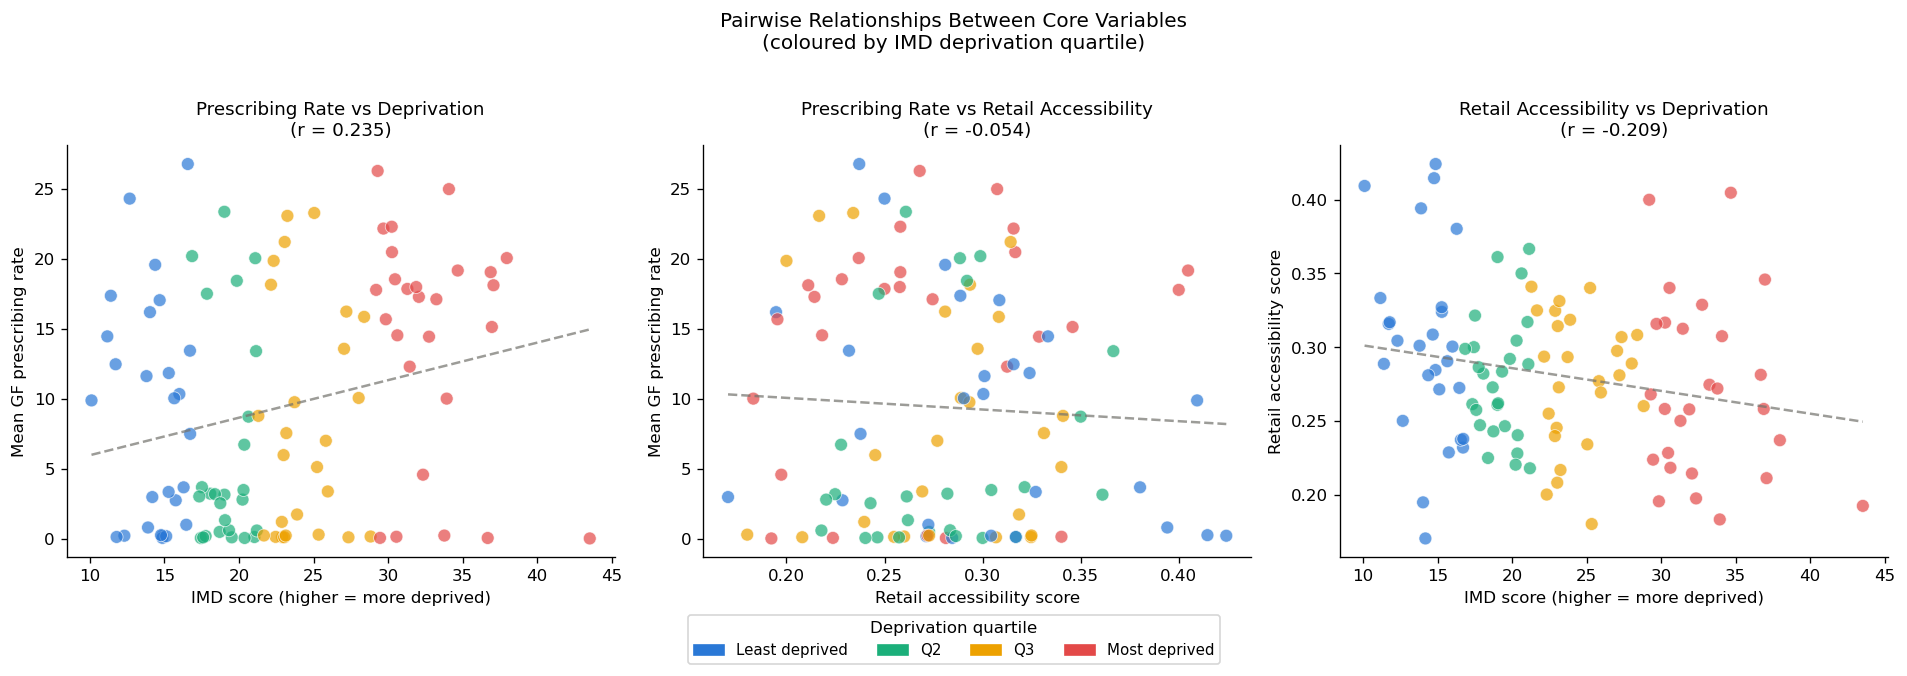


Correlations:
Prescribing vs IMD:     0.235
Prescribing vs Retail:  -0.054
Retail vs IMD:          -0.209


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Colour points by IMD quartile
imd_quartile = pd.qcut(df['imd_score_mean'], q=4, 
                        labels=['Least deprived', 'Q2', 'Q3', 'Most deprived'])
colors = {'Least deprived': '#2a78d6', 'Q2': '#1baf7a', 
          'Q3': '#eda100', 'Most deprived': '#e34948'}
color_vals = [colors[q] for q in imd_quartile]

# 1. Prescribing vs IMD
axes[0].scatter(df['imd_score_mean'], df['prescribing_rate_mean'], 
                c=color_vals, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
z = np.polyfit(df['imd_score_mean'], df['prescribing_rate_mean'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['imd_score_mean'].min(), df['imd_score_mean'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#73726c', linewidth=1.5, linestyle='--', alpha=0.7)
corr = df['imd_score_mean'].corr(df['prescribing_rate_mean'])
axes[0].set_title(f'Prescribing Rate vs Deprivation\n(r = {corr:.3f})', fontsize=11)
axes[0].set_xlabel('IMD score (higher = more deprived)')
axes[0].set_ylabel('Mean GF prescribing rate')

# 2. Prescribing vs Retail accessibility
axes[1].scatter(df['retail_accessibility_score'], df['prescribing_rate_mean'],
                c=color_vals, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
z2 = np.polyfit(df['retail_accessibility_score'], df['prescribing_rate_mean'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['retail_accessibility_score'].min(), 
                       df['retail_accessibility_score'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='#73726c', linewidth=1.5, linestyle='--', alpha=0.7)
corr2 = df['retail_accessibility_score'].corr(df['prescribing_rate_mean'])
axes[1].set_title(f'Prescribing Rate vs Retail Accessibility\n(r = {corr2:.3f})', fontsize=11)
axes[1].set_xlabel('Retail accessibility score')
axes[1].set_ylabel('Mean GF prescribing rate')

# 3. Retail accessibility vs IMD
axes[2].scatter(df['imd_score_mean'], df['retail_accessibility_score'],
                c=color_vals, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
z3 = np.polyfit(df['imd_score_mean'], df['retail_accessibility_score'], 1)
p3 = np.poly1d(z3)
axes[2].plot(x_line, p3(x_line), color='#73726c', linewidth=1.5, linestyle='--', alpha=0.7)
corr3 = df['imd_score_mean'].corr(df['retail_accessibility_score'])
axes[2].set_title(f'Retail Accessibility vs Deprivation\n(r = {corr3:.3f})', fontsize=11)
axes[2].set_xlabel('IMD score (higher = more deprived)')
axes[2].set_ylabel('Retail accessibility score')

# Legend
handles = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), title='Deprivation quartile')

plt.suptitle('Pairwise Relationships Between Core Variables\n(coloured by IMD deprivation quartile)',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\02_scatter_relationships.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(f"\nCorrelations:")
print(f"Prescribing vs IMD:     {corr:.3f}")
print(f"Prescribing vs Retail:  {corr2:.3f}")
print(f"Retail vs IMD:          {corr3:.3f}")

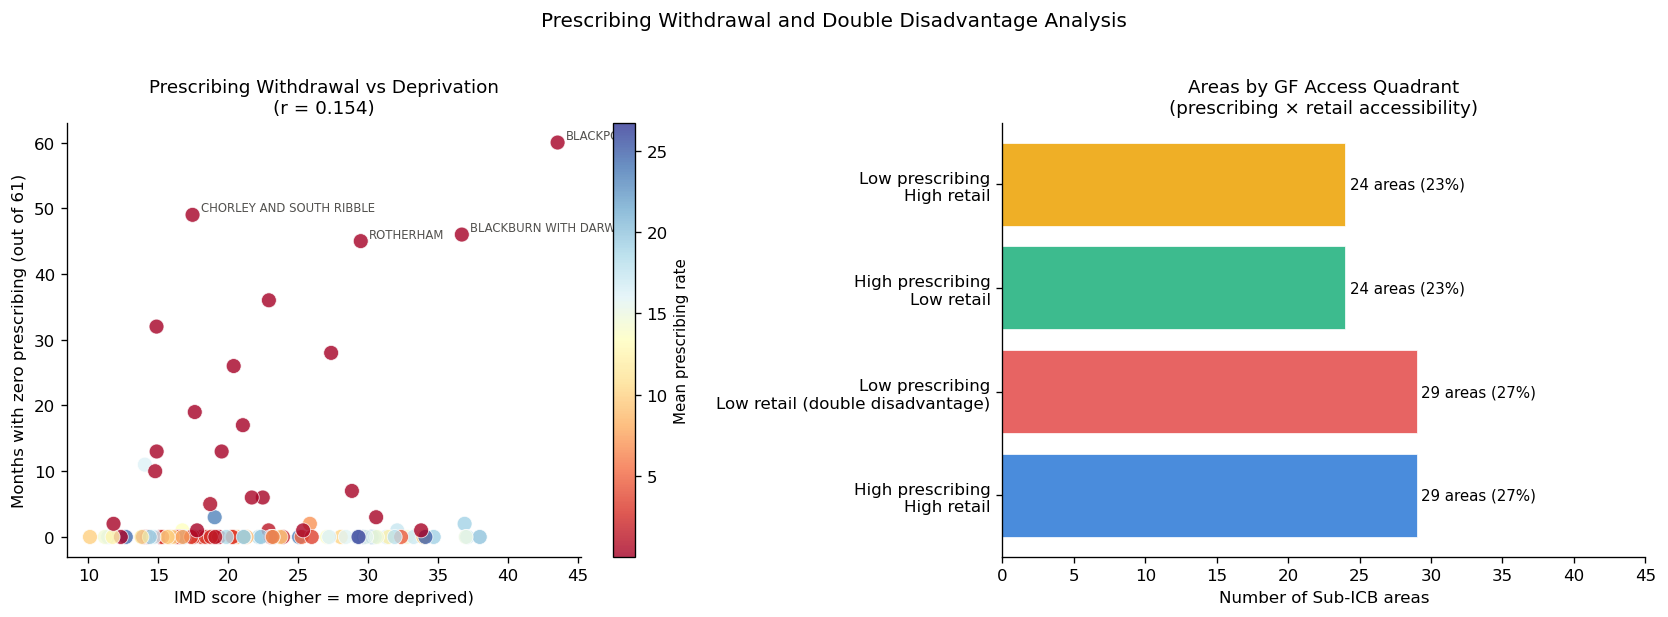


Withdrawal vs IMD correlation: 0.154

Quadrant breakdown:
quadrant
High prescribing\nHigh retail                        29
Low prescribing\nLow retail (double disadvantage)    29
High prescribing\nLow retail                         24
Low prescribing\nHigh retail                         24
Name: count, dtype: int64

Double disadvantage areas:
                                                  org_name  prescribing_rate_mean  retail_accessibility_score  imd_score_mean  months_zero
4                                            NHS BLACKPOOL               0.005195                    0.192308       43.527543           60
78                        NHS BRADFORD DISTRICT AND CRAVEN               0.212055                    0.271930       33.774105            1
47                                      NHS STOKE ON TRENT               4.560732                    0.197368       32.343815            0
35                                           NHS ROTHERHAM               0.045578                 

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Months zero vs IMD - key policy finding
scatter = axes[0].scatter(df['imd_score_mean'], df['months_zero'],
                          c=df['prescribing_rate_mean'], cmap='RdYlBu',
                          alpha=0.8, s=80, edgecolors='white', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Mean prescribing rate', fontsize=9)
corr_wz = df['imd_score_mean'].corr(df['months_zero'])
axes[0].set_title(f'Prescribing Withdrawal vs Deprivation\n(r = {corr_wz:.3f})', fontsize=11)
axes[0].set_xlabel('IMD score (higher = more deprived)')
axes[0].set_ylabel('Months with zero prescribing (out of 61)')

# Annotate extreme cases
for _, row in df[df['months_zero'] > 40].iterrows():
    axes[0].annotate(row['org_name'].replace('NHS ', ''), 
                     xy=(row['imd_score_mean'], row['months_zero']),
                     xytext=(5, 2), textcoords='offset points', fontsize=7,
                     color='#52514e')

# 2. Categorise areas by prescribing and retail accessibility
# Create quadrants
presc_median = df['prescribing_rate_mean'].median()
retail_median = df['retail_accessibility_score'].median()

def quadrant(row):
    high_presc = row['prescribing_rate_mean'] > presc_median
    high_retail = row['retail_accessibility_score'] > retail_median
    if high_presc and high_retail:
        return 'High prescribing\nHigh retail'
    elif high_presc and not high_retail:
        return 'High prescribing\nLow retail'
    elif not high_presc and high_retail:
        return 'Low prescribing\nHigh retail'
    else:
        return 'Low prescribing\nLow retail (double disadvantage)'

df['quadrant'] = df.apply(quadrant, axis=1)

quad_counts = df['quadrant'].value_counts()
quad_colors = {
    'High prescribing\nHigh retail': '#2a78d6',
    'High prescribing\nLow retail': '#1baf7a',
    'Low prescribing\nHigh retail': '#eda100',
    'Low prescribing\nLow retail (double disadvantage)': '#e34948'
}

bars = axes[1].barh(quad_counts.index, quad_counts.values,
                    color=[quad_colors[q] for q in quad_counts.index],
                    alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, quad_counts.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val} areas ({val/106*100:.0f}%)',
                 va='center', fontsize=9)

axes[1].set_title('Areas by GF Access Quadrant\n(prescribing × retail accessibility)', fontsize=11)
axes[1].set_xlabel('Number of Sub-ICB areas')
axes[1].set_xlim(0, 45)

plt.suptitle('Prescribing Withdrawal and Double Disadvantage Analysis',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\03_withdrawal_quadrants.png',
            bbox_inches='tight', dpi=150)
plt.show()

print(f"\nWithdrawal vs IMD correlation: {corr_wz:.3f}")
print(f"\nQuadrant breakdown:")
print(df['quadrant'].value_counts())
print(f"\nDouble disadvantage areas:")
dd = df[df['quadrant'] == 'Low prescribing\nLow retail (double disadvantage)']
print(dd[['org_name', 'prescribing_rate_mean', 'retail_accessibility_score', 
          'imd_score_mean', 'months_zero']].sort_values('imd_score_mean', ascending=False).to_string())

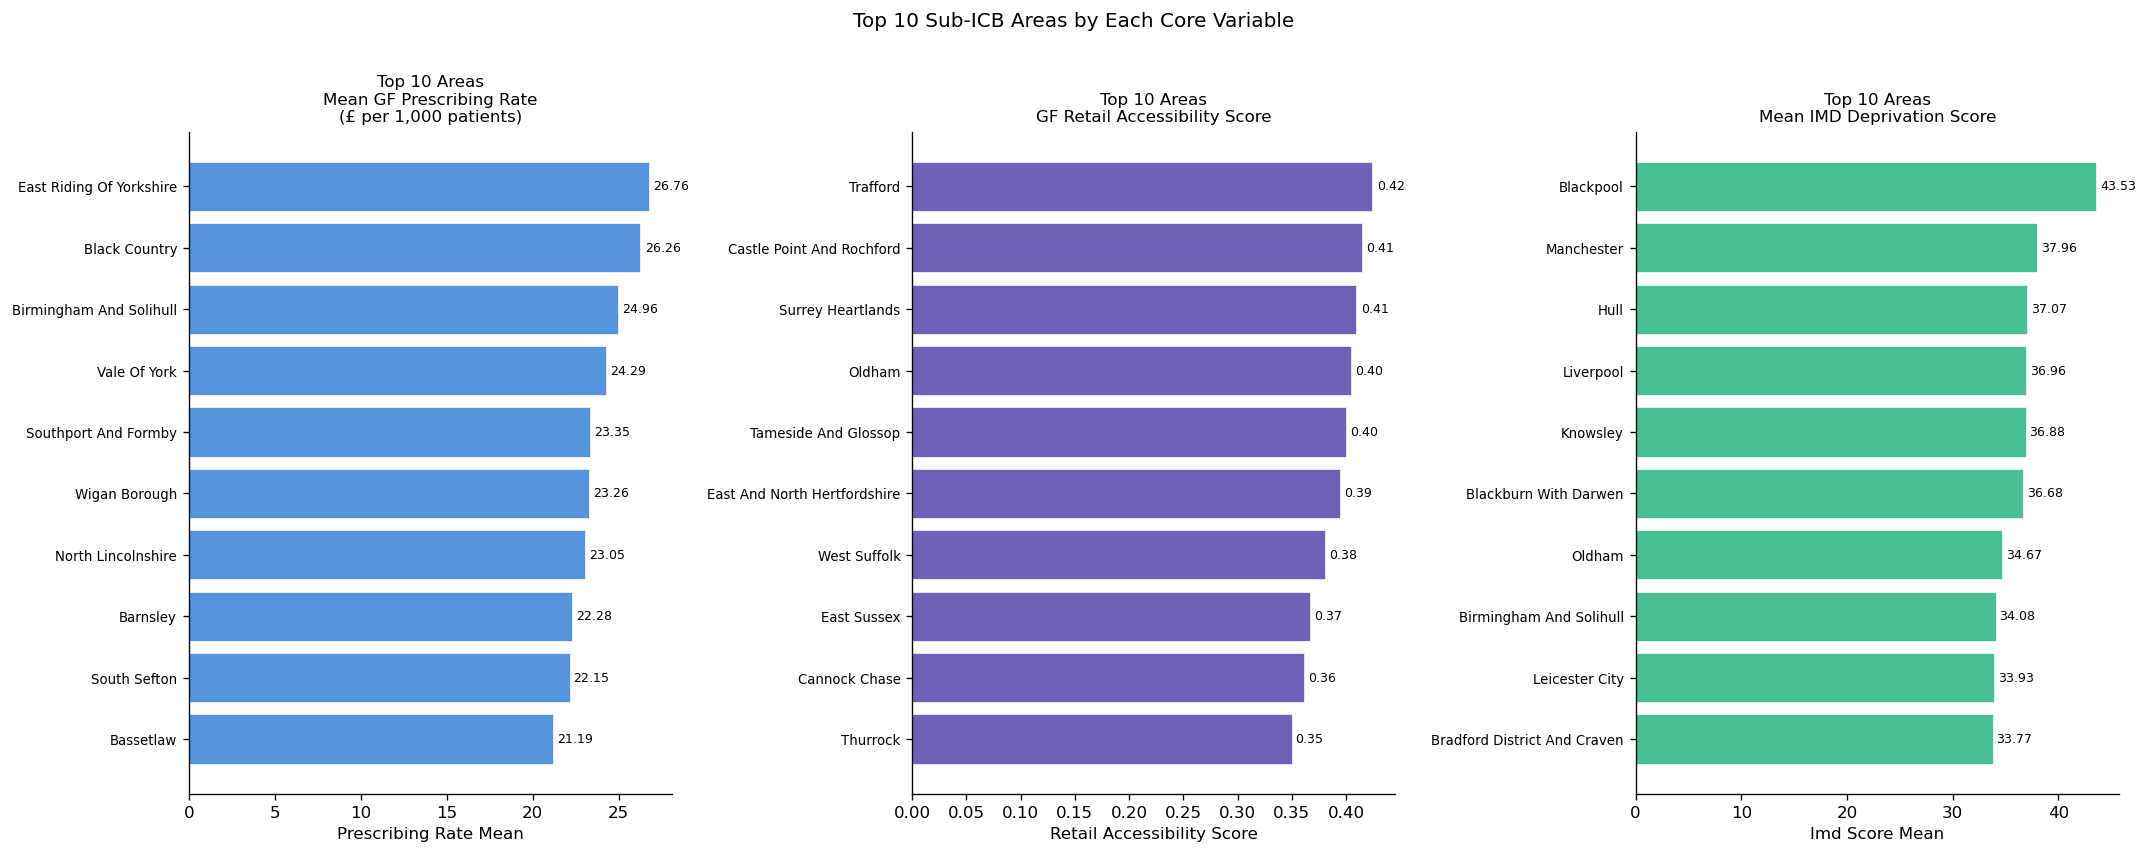

BOTTOM 10 AREAS — Prescribing Rate (near-zero provision):
                               org_name  prescribing_rate_mean  months_zero  imd_score_mean  retail_accessibility_score
4                         NHS BLACKPOOL               0.005195           60       43.527543                    0.192308
3             NHS BLACKBURN WITH DARWEN               0.037698           46       36.682912                    0.281250
7          NHS CHORLEY AND SOUTH RIBBLE               0.039176           49       17.439579                    0.300000
102  NHS SHROPSHIRE, TELFORD AND WREKIN               0.039220           26       20.379051                    0.240260
35                        NHS ROTHERHAM               0.045578           45       29.460582                    0.223684
52                        NHS MID ESSEX               0.045763           32       14.864769                    0.284483
85                 NHS NORTHAMPTONSHIRE               0.081263           19       17.598054           

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

vars_config = [
    ('prescribing_rate_mean', 'Mean GF Prescribing Rate\n(£ per 1,000 patients)', '#2a78d6'),
    ('retail_accessibility_score', 'GF Retail Accessibility Score', '#4a3aa7'),
    ('imd_score_mean', 'Mean IMD Deprivation Score', '#1baf7a'),
]

for ax, (col, title, color) in zip(axes, vars_config):
    top10 = df.nlargest(10, col)[['org_name', col]].sort_values(col)
    names = top10['org_name'].str.replace('NHS ', '').str.title()
    vals = top10[col]
    
    bars = ax.barh(range(len(names)), vals, color=color, alpha=0.8,
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(f'Top 10 Areas\n{title}', fontsize=10)
    ax.set_xlabel(col.replace('_', ' ').title())
    
    for bar, val in zip(bars, vals):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=7.5)

plt.suptitle('Top 10 Sub-ICB Areas by Each Core Variable',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\04_top10_areas.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Also print bottom 10 for prescribing
print("BOTTOM 10 AREAS — Prescribing Rate (near-zero provision):")
print(df.nsmallest(10, 'prescribing_rate_mean')[
    ['org_name', 'prescribing_rate_mean', 'months_zero', 
     'imd_score_mean', 'retail_accessibility_score']].to_string())

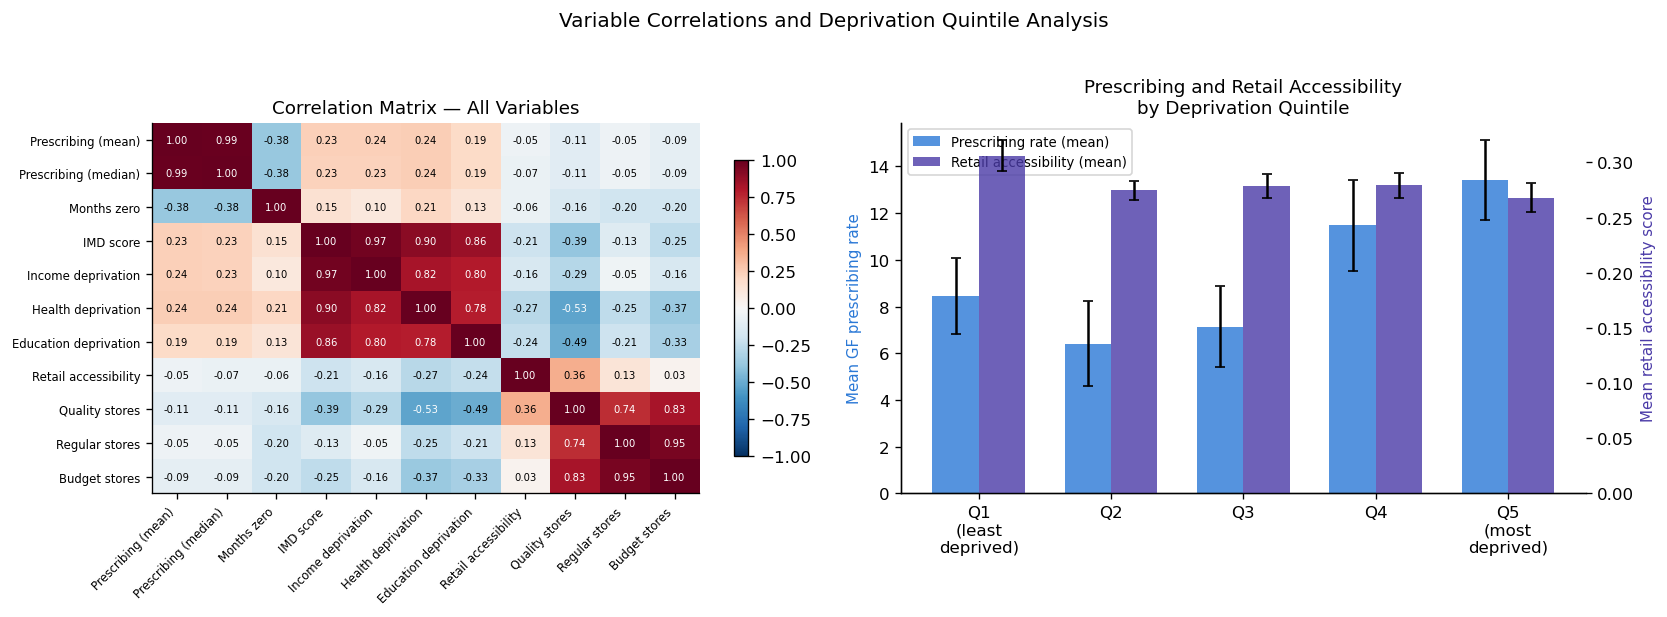


Mean values by IMD quintile:
            imd_quintile  presc_mean  retail_mean  months_zero_mean
0  Q1\n(least\ndeprived)       8.441        0.306             3.091
1                     Q2       6.417        0.275             4.333
2                     Q3       7.144        0.278             4.381
3                     Q4      11.480        0.279             3.952
4   Q5\n(most\ndeprived)      13.414        0.268             5.381


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Correlation heatmap of all numeric variables
corr_vars = ['prescribing_rate_mean', 'prescribing_rate_median',
             'months_zero', 'imd_score_mean', 'income_score_mean',
             'health_score_mean', 'education_score_mean',
             'retail_accessibility_score', 'quality_stores', 
             'regular_stores', 'budget_stores']

corr_labels = ['Prescribing (mean)', 'Prescribing (median)',
               'Months zero', 'IMD score', 'Income deprivation',
               'Health deprivation', 'Education deprivation',
               'Retail accessibility', 'Quality stores',
               'Regular stores', 'Budget stores']

corr_matrix = df[corr_vars].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
im = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[0], shrink=0.8)

axes[0].set_xticks(range(len(corr_labels)))
axes[0].set_yticks(range(len(corr_labels)))
axes[0].set_xticklabels(corr_labels, rotation=45, ha='right', fontsize=7)
axes[0].set_yticklabels(corr_labels, fontsize=7)

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_matrix.iloc[i, j]
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(val) > 0.5 else 'black')

axes[0].set_title('Correlation Matrix — All Variables', fontsize=11)

# 2. Mean prescribing rate and retail accessibility by IMD quintile
df['imd_quintile'] = pd.qcut(df['imd_score_mean'], q=5,
                              labels=['Q1\n(least\ndeprived)', 'Q2', 'Q3', 'Q4',
                                      'Q5\n(most\ndeprived)'])

quintile_stats = df.groupby('imd_quintile', observed=True).agg(
    presc_mean=('prescribing_rate_mean', 'mean'),
    presc_se=('prescribing_rate_mean', 'sem'),
    retail_mean=('retail_accessibility_score', 'mean'),
    retail_se=('retail_accessibility_score', 'sem'),
    months_zero_mean=('months_zero', 'mean')
).reset_index()

x = np.arange(len(quintile_stats))
width = 0.35

bars1 = axes[1].bar(x - width/2, quintile_stats['presc_mean'], width,
                    color='#2a78d6', alpha=0.8, label='Prescribing rate (mean)',
                    yerr=quintile_stats['presc_se'], capsize=3)

ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width/2, quintile_stats['retail_mean'], width,
                color='#4a3aa7', alpha=0.8, label='Retail accessibility (mean)',
                yerr=quintile_stats['retail_se'], capsize=3)

axes[1].set_xticks(x)
axes[1].set_xticklabels(quintile_stats['imd_quintile'])
axes[1].set_ylabel('Mean GF prescribing rate', color='#2a78d6', fontsize=9)
ax2.set_ylabel('Mean retail accessibility score', color='#4a3aa7', fontsize=9)
axes[1].set_title('Prescribing and Retail Accessibility\nby Deprivation Quintile', fontsize=11)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Variable Correlations and Deprivation Quintile Analysis',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()

plt.savefig(r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\05_correlations_quintiles.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\nMean values by IMD quintile:")
print(quintile_stats[['imd_quintile', 'presc_mean', 'retail_mean', 
                        'months_zero_mean']].round(3).to_string())

In [9]:
# Cell 7 — EDA summary statistics table for the report
print("="*70)
print("EDA SUMMARY — KEY STATISTICS FOR REPORT")
print("="*70)

print("\n1. PRESCRIBING VARIABLE")
print(f"   Areas with complete withdrawal (>50 months zero): "
      f"{(df['months_zero'] > 50).sum()} areas")
print(f"   Areas with partial withdrawal (1-50 months zero): "
      f"{((df['months_zero'] > 0) & (df['months_zero'] <= 50)).sum()} areas")
print(f"   Areas with consistent prescribing (0 months zero): "
      f"{(df['months_zero'] == 0).sum()} areas")
print(f"   Coefficient of variation: "
      f"{df['prescribing_rate_mean'].std()/df['prescribing_rate_mean'].mean():.2f}")

print("\n2. RETAIL ACCESSIBILITY VARIABLE")
print(f"   Areas below median retail score (<{df['retail_accessibility_score'].median():.3f}): "
      f"{(df['retail_accessibility_score'] < df['retail_accessibility_score'].median()).sum()}")
print(f"   Areas with no quality stores: "
      f"{(df['quality_stores'] == 0).sum()}")
print(f"   Mean quality stores per area: {df['quality_stores'].mean():.1f}")
print(f"   Mean budget stores per area: {df['budget_stores'].mean():.1f}")

print("\n3. DEPRIVATION VARIABLE")
print(f"   IMD score range: {df['imd_score_mean'].min():.1f} – {df['imd_score_mean'].max():.1f}")
print(f"   Most deprived area: {df.loc[df['imd_score_mean'].idxmax(), 'org_name']}")
print(f"   Least deprived area: {df.loc[df['imd_score_mean'].idxmin(), 'org_name']}")

print("\n4. DOUBLE DISADVANTAGE")
presc_median = df['prescribing_rate_mean'].median()
retail_median = df['retail_accessibility_score'].median()
dd = df[(df['prescribing_rate_mean'] < presc_median) & 
        (df['retail_accessibility_score'] < retail_median)]
print(f"   Areas in double disadvantage: {len(dd)} ({len(dd)/106*100:.0f}%)")
print(f"   Mean IMD of double disadvantage areas: {dd['imd_score_mean'].mean():.1f}")
print(f"   Mean IMD of all other areas: {df[~df.index.isin(dd.index)]['imd_score_mean'].mean():.1f}")
print(f"   Most extreme case: {df.loc[df['months_zero'].idxmax(), 'org_name']} "
      f"({df['months_zero'].max()} months zero, IMD {df.loc[df['months_zero'].idxmax(), 'imd_score_mean']:.1f})")

print("\n5. CORRELATIONS (Pearson r)")
print(f"   Prescribing vs IMD:              {df['prescribing_rate_mean'].corr(df['imd_score_mean']):.3f}")
print(f"   Prescribing vs Retail:           {df['prescribing_rate_mean'].corr(df['retail_accessibility_score']):.3f}")
print(f"   Retail vs IMD:                   {df['retail_accessibility_score'].corr(df['imd_score_mean']):.3f}")
print(f"   Retail vs Health deprivation:    {df['retail_accessibility_score'].corr(df['health_score_mean']):.3f}")
print(f"   Months zero vs IMD:              {df['months_zero'].corr(df['imd_score_mean']):.3f}")

# Save EDA-enriched dataset
df.to_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_eda.csv',
          index=False)
print("\nSaved EDA-enriched dataset.")

EDA SUMMARY — KEY STATISTICS FOR REPORT

1. PRESCRIBING VARIABLE
   Areas with complete withdrawal (>50 months zero): 1 areas
   Areas with partial withdrawal (1-50 months zero): 28 areas
   Areas with consistent prescribing (0 months zero): 77 areas
   Coefficient of variation: 0.90

2. RETAIL ACCESSIBILITY VARIABLE
   Areas below median retail score (<0.281): 53
   Areas with no quality stores: 5
   Mean quality stores per area: 7.5
   Mean budget stores per area: 111.8

3. DEPRIVATION VARIABLE
   IMD score range: 10.1 – 43.5
   Most deprived area: NHS BLACKPOOL
   Least deprived area: NHS SURREY HEARTLANDS

4. DOUBLE DISADVANTAGE
   Areas in double disadvantage: 29 (27%)
   Mean IMD of double disadvantage areas: 22.4
   Mean IMD of all other areas: 22.9
   Most extreme case: NHS BLACKPOOL (60 months zero, IMD 43.5)

5. CORRELATIONS (Pearson r)
   Prescribing vs IMD:              0.235
   Prescribing vs Retail:           -0.054
   Retail vs IMD:                   -0.209
   Retail vs 